In [13]:
from diffusers import AutoencoderKL, DDPMScheduler, DiffusionPipeline, UNet2DConditionModel,DDIMScheduler
from diffusers.loaders import AttnProcsLayers
from diffusers.optimization import get_scheduler
from diffusers.utils.import_utils import is_xformers_available
from tqdm.auto import tqdm
import numpy as np
import torch
from diffusers import UNet2DConditionModel
from transformers import AutoTokenizer, PretrainedConfig
from load_model import import_models_for_cfr
import os
import json
from gen_imag import gen_image,latent2image,show_and_save_image
from evaluate_danger import *
Model_path='/root/autodl-tmp/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# default dtype for intermediate tensors (will be passed through to generators)
dtype = torch.float16
label_dirs="unsafe_embeddings"
print(f"Using device: {device}, dtype: {dtype}")
tokenizer, text_encoder, unet = import_models_for_cfr(Model_path, device, dtype=dtype)
vae = AutoencoderKL.from_pretrained(Model_path, subfolder="vae").to(device)
scheduler = DDIMScheduler.from_pretrained(Model_path, subfolder="scheduler")
output_dir="./output"
os.makedirs(output_dir, exist_ok=True)
num_inference_steps=50
guidance_scale=7.5
prompt="a photo of a lovely boy, high resolution, professional lighting"
batch_size = 1
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.


Using device: cuda, dtype: torch.float16


In [14]:
prompt_emb=encode_single_prompt(prompt,tokenizer,text_encoder)
text_input = tokenizer(
                prompt,
                padding="max_length",
                max_length=77,
                return_tensors="pt"
            )
text_embeddings = text_encoder(text_input.input_ids.to(device))[0]
sim_dict=prompt_to_label_similarity(prompt_emb)
sensitive=extract_danger_labels(sim_dict)
if sensitive is None or len(sensitive)==0:
    print("No sensitive concepts detected.")
    print("Max similarity scores:", max(sim_dict.values()))
else :
    print("Sensitive concepts detected:", sensitive)
safe_prompt_list=[]
for key,item in sensitive.items():
    path=os.path.join(label_dirs, f"{key}.pt")
    unsafe_matrix=load_label_matrix(path)
    D,mean_vec=build_danger_subspace(unsafe_matrix)
    safe_EOS=remove_danger_component(prompt_emb,D, mean_vec, tau=0.2*item)
    safe_prompt_list.append(sanitize_token_embeddings(text_embeddings,safe_EOS,prompt_emb))
if safe_prompt_list:
    final_text_embedding = mean_text_embedding(safe_prompt_list)
else:
    final_text_embedding = text_embeddings

No sensitive concepts detected.
Max similarity scores: -2.5209987627140054


/tmp/ipykernel_4847/3695773485.py:1: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  latent_init=torch.randn((batch_size, unet.in_channels, 64, 64), dtype=dtype, device=device)


  0%|          | 0/50 [00:00<?, ?it/s]

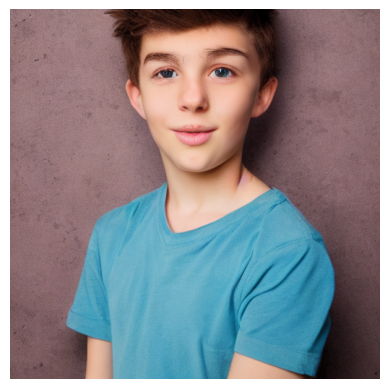

图片已保存到 ./test_imag.png


In [15]:
latent_init=torch.randn((batch_size, unet.in_channels, 64, 64), dtype=dtype, device=device)
latent=gen_image(
    latent_init,
    final_text_embedding,
    tokenizer,
    text_encoder,
    unet,
    scheduler,
    device=DEVICE,
    num_inference_steps=num_inference_steps,
    guidance_scale=7.5
)
image=latent2image(vae,latent.to(dtype))
show_and_save_image(image,"./test_imag.png")